# Part 2 (of 3): Temperature Calibration for HI Spectroscopy

This notebook is the **Part-2 calibration stage** in a three-part investigation of the Milky Way HI profile.
Its role is to convert measured PSD/count units into a physically interpretable temperature scale and export a calibration artifact consumed by downstream science analysis.

## Position in the 3-part workflow

1. **Part 1**: instrument/signal-chain characterization and observing setup.
2. **Part 2 (this notebook)**: hot/cold temperature calibration, uncertainty decomposition, and export of calibration products.
3. **Part 3**: velocity-frame correction, baseline subtraction, Gaussian decomposition, and astrophysical interpretation.

## Requirement traceability

This notebook is aligned to:

- `src/ugradio/lab_bighorn/bighorn.tex`
  - hot/cold (blackbody vs cold-sky) intensity calibration context,
  - system-temperature decomposition and absolute temperature scaling goals.
- `src/ugradio/lab_bighorn/cal_intensity.tex`
  - $P_j = G_j\,T_{\mathrm{sys}}(\nu)$ model,
  - cool-method idea: shape ratio times a single scalar temperature scale,
  - first-order error-propagation treatment.
- `src/ugradio/lab_bighorn/horn_signal_chain_test.tex`
  - use of measured signal-chain behavior via required ingest of `equipment_calibration_results_v2.npz`.

`coords.tex` (rotation-matrix coordinate transforms) is out of scope here and handled in downstream analysis notebooks.


## Global assumptions, priors, and scope

- Two-load calibration constants used in this notebook:
  - `T_HOT = 310 K` (human-body blackbody proxy filling the horn aperture).
  - `T_COLD = 30 K` (effective cold-sky reference for this setup/pointing).
- Load-prior uncertainties:
  - `SIGMA_T_HOT = 5 K`, `SIGMA_T_COLD = 2 K`.
- Hardware artifact dependency is hard-gated:
  - `equipment_calibration_results_v2.npz` must exist and pass schema checks.
- Beam-filling default is `eta_bf = 1.0`, so by default reported brightness-equivalent temperature satisfies
  $$T_{B,\mathrm{eq}} = T_A.$$ 
- Horn geometry and $\lambda^2/A$ are retained as diagnostics, not direct Y-factor multipliers.
- RFI handling uses residual sigma clipping after Savitzky-Golay baseline estimation.

### Scope boundary for this Part-2 notebook

This notebook calibrates $T_{\mathrm{rx}}$, $T_{\mathrm{sys}}$, and frequency-dependent temperature scaling products.
Full astrophysical profile extraction (velocity-frame products, baseline/line modeling, aperture-efficiency inference) is part of downstream analysis.


## Radiometric model and derivation used in code

### 1) Backend model

Following `cal_intensity.tex`, measured channel power is modeled as

$$
P_j = G_j\,T_{\mathrm{sys}}(\nu),
$$

with channel-dependent gain $G_j$ and system temperature contributions.

### 2) Two-load Y-factor solve

For hot/cold measurements through the same chain,

$$
Y \equiv \frac{P_{\mathrm{hot}}}{P_{\mathrm{cold}}}
= \frac{T_{\mathrm{hot}}+T_{\mathrm{rx}}}{T_{\mathrm{cold}}+T_{\mathrm{rx}}},
$$

which gives

$$
T_{\mathrm{rx}} = \frac{T_{\mathrm{hot}} - YT_{\mathrm{cold}}}{Y - 1},
\qquad
T_{\mathrm{sys}} = T_{\mathrm{cold}} + T_{\mathrm{rx}}.
$$

### 3) Explicit equivalence to cool-method scalar scaling

Using $Y=P_{\mathrm{hot}}/P_{\mathrm{cold}}$,

$$
T_{\mathrm{sys}} = \frac{T_{\mathrm{hot}}-T_{\mathrm{cold}}}{Y-1}
= \frac{P_{\mathrm{cold}}}{P_{\mathrm{hot}}-P_{\mathrm{cold}}}(T_{\mathrm{hot}}-T_{\mathrm{cold}}),
$$

which is the same scalar factor used by the cool-method derivation when numerator/denominator are evaluated on the same channel set.

### 4) Frequency-dependent antenna-temperature mapping

With a cold-reference profile $P_{\mathrm{cold,ref}}(\nu)$,

$$
T_A(\nu) = P_{\mathrm{obs}}(\nu)\,\frac{T_{\mathrm{cold}}+T_{\mathrm{rx}}}{P_{\mathrm{cold,ref}}(\nu)} - T_{\mathrm{rx}}.
$$

At 1.42 GHz, Rayleigh-Jeans is an excellent approximation for this lab context, so temperature-domain reporting is physically well motivated.


## Error propagation and validity conditions

### Error model used here

Per `cal_intensity.tex`, first-order propagation follows:

- For sums/differences: $\sigma_q^2 = \sigma_x^2 + \sigma_y^2$.
- For products/ratios: $\left(\sigma_q/q\right)^2 = \left(\sigma_x/x\right)^2 + \left(\sigma_y/y\right)^2$.

Implemented uncertainty decomposition for $T_{\mathrm{rx}}$:

- `sigma_T_rx_meas`: propagated measurement term from $P_{\mathrm{hot}}$, $P_{\mathrm{cold}}$ via $Y$.
- `sigma_T_rx_loads`: load-prior term from `SIGMA_T_HOT`, `SIGMA_T_COLD`.
- `sigma_T_rx_hw`: hardware-systematic term from equipment linearity/chain diagnostics.
- `sigma_T_rx_total`: quadrature sum of the three terms.

### Conditions enforced in this notebook

- finite, positive powers in ratio operations,
- physical Y-factor domain $Y>1$,
- common-mask solve policy for hot/cold equivalence checks,
- explicit masking of invalid/RFI channels before scalar solves.


In [1]:
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ugradiolab import Spectrum

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['figure.dpi'] = 300

DATA_ROOT = Path('data/lab02') if Path('data/lab02').exists() else Path('../../data/lab02')
NB_DIR = Path('labs/02') if Path('labs/02').exists() else Path('.')
CACHE_DIR = NB_DIR / 'cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)

EQ_CAL_CANDIDATES = [
    CACHE_DIR / 'equipment_calibration_results_v2.npz',
    NB_DIR / 'equipment_calibration_results_v2.npz',
    Path('equipment_calibration_results_v2.npz'),
    Path('../equipment_calibration_results_v2.npz'),
]

CAL_CAL_CANDIDATES = [
    CACHE_DIR / 'calibration_results_v2.npz',
    NB_DIR / 'calibration_results_v2.npz',
    Path('calibration_results_v2.npz'),
    Path('../calibration_results_v2.npz'),
]

REPORT_DIR_CANDIDATES = [
    Path('labs/02/report'),
    Path('report'),
    Path('../report'),
]

EQ_V2_KEYS_REQUIRED = [
    'schema_version',
    'model.alpha_db_per_m', 'model.sigma_alpha_db_per_m',
    'length.unknown_m', 'length.sigma_unknown_m',
    'response.freq_offset_mhz', 'response.fir_power_norm', 'response.sum_power_norm',
    'response.passband_mask', 'response.eval_mask',
    'linearity.highest_unclipped_setpoint_dbm', 'linearity.first_clipped_setpoint_dbm',
    'linearity.sweep_rmse_db',
]

EQ_KEYS_REQUIRED = [
    'schema_version',
    'alpha_db_per_m', 'sigma_alpha_db_per_m',
    'unknown_cable_length_m', 'unknown_cable_length_sigma_m',
    'freq_offset_mhz', 'fir_response_norm', 'sum_response_norm',
    'passband_mask', 'combined_eval_mask', 'response_floor',
    'sweep_rmse_db',
    'highest_unclipped_setpoint_dbm', 'first_clipped_setpoint_dbm',
]

EXPECTED_EQUIPMENT_SCHEMA_VERSION = '2.0.0'

# ── Temperature assumptions ───────────────────────────────────────────────────
T_HOT          = 310.0   # K  — human body temperature
T_COLD         = 30.0    # K  — effective cold-reference sky for this pointing
SIGMA_T_HOT    = 5.0     # K  — systematic uncertainty on T_hot
SIGMA_T_COLD   = 2.0     # K  — systematic uncertainty on T_cold

# ── Hardware-systematic model controls ───────────────────────────────────────
HARDWARE_RESPONSE_MIN = 1e-8
HARDWARE_RESPONSE_COLLAPSE_THRESH_FRAC = 0.25
HARDWARE_RESPONSE_RELATIVE_SUPPORT_THRESH = 0.50

# ── Horn geometry / beam assumptions (diagnostics) ──────────────────────────
HORN_PARALLEL_M             = 0.80
HORN_PERP_HORIZON_M         = 0.90
HORN_APERTURE_AREA_M2       = HORN_PARALLEL_M * HORN_PERP_HORIZON_M
BEAM_FILLING_FACTOR_DEFAULT = 1.0   # eta_bf; T_B = T_A / eta_bf

# ── Constants for optional beam diagnostics ──────────────────────────────────
C_LIGHT_M_S                 = 299_792_458.0
HI_REST_FREQ_HZ             = 1_420_405_751.768
OMEGA_BEAM_APPROX_SR_HI     = (C_LIGHT_M_S / HI_REST_FREQ_HZ) ** 2 / HORN_APERTURE_AREA_M2

# ── RFI flagging ──────────────────────────────────────────────────────────────
RFI_SIGMA       = 5      # sigma-clip threshold
SAVGOL          = dict(method='savgol', window_length=257, polyorder=3)
ROLLING_WIDTH   = 200    # bins for local std estimate

print(f'DATA_ROOT   : {DATA_ROOT.resolve()}')
print(f'T_hot       : {T_HOT} K  (sigma = {SIGMA_T_HOT} K)')
print(f'T_cold      : {T_COLD} K  (sigma = {SIGMA_T_COLD} K)')
print(f'Horn dims   : {HORN_PARALLEL_M:.2f} m x {HORN_PERP_HORIZON_M:.2f} m  (A = {HORN_APERTURE_AREA_M2:.3f} m^2)')
print(f'eta_bf (default): {BEAM_FILLING_FACTOR_DEFAULT:.3f}  (T_B = T_A / eta_bf)')
print(f'Omega_beam approx at HI from lambda^2/A: {OMEGA_BEAM_APPROX_SR_HI:.4f} sr (diagnostic only)')
print(f'Expected equipment schema version: {EXPECTED_EQUIPMENT_SCHEMA_VERSION}')
print('Equipment artifact candidates:')
for p in EQ_CAL_CANDIDATES:
    print(f'  - {p}')

/Users/junruiting/GitHub/ay-121/.venv/lib/python3.14/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


DATA_ROOT   : /Users/junruiting/GitHub/ay-121/data/lab02
T_hot       : 310.0 K  (sigma = 5.0 K)
T_cold      : 30.0 K  (sigma = 2.0 K)
Horn dims   : 0.80 m x 0.90 m  (A = 0.720 m^2)
eta_bf (default): 1.000  (T_B = T_A / eta_bf)
Omega_beam approx at HI from lambda^2/A: 0.0619 sr (diagnostic only)
Expected equipment schema version: 2.0.0
Equipment artifact candidates:
  - cache/equipment_calibration_results_v2.npz
  - equipment_calibration_results_v2.npz
  - equipment_calibration_results_v2.npz
  - ../equipment_calibration_results_v2.npz


## Helper functions and implementation modules

These helpers implement the derivations above in reusable numerical operators:

- I/O and artifact schema validation (`load_lo_pair`, `load_equipment_artifact`, `validate_equipment_schema`).
- Masking and robust power summaries (`sigma_clip_rfi_mask`, `masked_total_power`, `masked_mean_power`).
- Hardware-response mapping/correction (`hardware_response_on_axis`, `apply_hardware_response_correction`).
- Calibration primitives (`measure_y_factor`, `build_cold_reference_profile`, `antenna_temp_scale`).


In [2]:
# ── I/O ───────────────────────────────────────────────────────────────────────

def load_lo_pair(spectra_dir: Path) -> dict:
    """Load LO1420 and LO1421 Spectra from a *_combined_spectra directory.

    Returns dict keyed by LO integer MHz: {1420: Spectrum, 1421: Spectrum}.
    """
    spectra_dir = Path(spectra_dir)
    files = sorted(spectra_dir.glob('*.npz'))
    if not files:
        raise FileNotFoundError(f'No .npz files found in {spectra_dir}')
    pairs = {}
    for f in files:
        spec = Spectrum.load(f)
        lo_mhz = int(round(spec.center_freq / 1e6))
        pairs[lo_mhz] = spec
    if 1420 not in pairs or 1421 not in pairs:
        raise ValueError(f'Expected LO 1420 and LO1421 in {spectra_dir}, got {list(pairs.keys())}')
    return pairs


def lo_center_bin_index(spectrum: Spectrum) -> int:
    return int(spectrum.bin_at(float(spectrum.center_freq)))


def lo_analysis_mask(spectrum: Spectrum) -> np.ndarray:
    mask = np.ones(np.asarray(spectrum.psd).shape, dtype=bool)
    idx_center = lo_center_bin_index(spectrum)
    if 0 <= idx_center < mask.size:
        mask[idx_center] = False
    if not np.any(mask):
        raise ValueError('Spectrum has no channels left after removing the LO center bin.')
    return mask


def combine_spectrum_mask(spectrum: Spectrum,
                          *masks: np.ndarray,
                          require_nonempty: bool = False) -> np.ndarray:
    combined = lo_analysis_mask(spectrum)
    for mask in masks:
        if mask is None:
            continue
        arr = np.asarray(mask, bool)
        if arr.shape != combined.shape:
            raise ValueError(f'Mask shape {arr.shape} does not match spectrum shape {combined.shape}.')
        combined &= arr
    if require_nonempty and not np.any(combined):
        raise ValueError('No analysis channels remain after masking the LO center bin.')
    return combined


def masked_spectrum_values(spectrum: Spectrum,
                           values: np.ndarray | None = None,
                           mask: np.ndarray | None = None,
                           fill_value=np.nan) -> np.ndarray:
    base = spectrum.psd_values(mask_dc=True) if values is None else spectrum.mask_dc_bin(values)
    arr = np.array(base, dtype=float, copy=True)
    combined = combine_spectrum_mask(spectrum, mask)
    arr[~combined] = fill_value
    return arr


def fill_masked_spectrum_values(spectrum: Spectrum,
                                values: np.ndarray | None = None,
                                mask: np.ndarray | None = None) -> np.ndarray:
    arr = masked_spectrum_values(spectrum, values=values, mask=mask)
    finite = np.isfinite(arr)
    if finite.sum() < 2:
        raise ValueError('Need at least two finite channels to interpolate across the LO bin.')
    idx = np.arange(arr.size, dtype=float)
    filled = arr.copy()
    filled[~finite] = np.interp(idx[~finite], idx[finite], arr[finite])
    return filled


def smooth_series(values: np.ndarray, smooth_kwargs: dict) -> np.ndarray:
    arr = np.asarray(values, float)
    method = smooth_kwargs.get('method', 'savgol')

    if method == 'savgol':
        from scipy.signal import savgol_filter

        window_length = int(smooth_kwargs.get('window_length', 129))
        if window_length % 2 == 0:
            window_length += 1
        if window_length >= arr.size:
            window_length = arr.size - 1 if arr.size % 2 == 0 else arr.size
        if window_length < 3:
            return arr.copy()
        polyorder = min(int(smooth_kwargs.get('polyorder', 3)), window_length - 1)
        return savgol_filter(arr, window_length=window_length, polyorder=polyorder, mode='interp')

    if method == 'boxcar':
        width = int(smooth_kwargs.get('M', 64))
        if width <= 1:
            return arr.copy()
        kernel = np.ones(width, float) / width
        return np.convolve(arr, kernel, mode='same')

    if method == 'gaussian':
        from scipy.ndimage import gaussian_filter1d
        return gaussian_filter1d(arr, sigma=float(smooth_kwargs.get('sigma', 32)))

    raise ValueError(f'Unsupported smoothing method for LO-masked series: {method!r}')


def _available_keys(npz_obj):
    if hasattr(npz_obj, 'files'):
        return list(npz_obj.files)
    return list(npz_obj.keys())


def require_keys(npz_obj, keys, label):
    available = _available_keys(npz_obj)
    missing = [k for k in keys if k not in available]
    if missing:
        raise KeyError(f'{label} missing required keys: {missing}')


def npz_to_dict(npz_obj):
    return {name: np.asarray(npz_obj[name]) for name in npz_obj.files}


def normalize_equipment_artifact(eq_dict):
    eq = dict(eq_dict)
    require_keys(eq, EQ_V2_KEYS_REQUIRED, 'equipment_calibration_results_v2.npz')

    eq.setdefault('alpha_db_per_m', eq['model.alpha_db_per_m'])
    eq.setdefault('sigma_alpha_db_per_m', eq['model.sigma_alpha_db_per_m'])
    eq.setdefault('unknown_cable_length_m', eq['length.unknown_m'])
    eq.setdefault('unknown_cable_length_sigma_m', eq['length.sigma_unknown_m'])
    eq.setdefault('freq_offset_mhz', eq['response.freq_offset_mhz'])
    eq.setdefault('fir_response_norm', eq['response.fir_power_norm'])
    eq.setdefault('sum_response_norm', eq['response.sum_power_norm'])
    eq.setdefault('combined_response_norm', eq.get('response.combined_power_norm', np.asarray(eq['response.fir_power_norm'], float) * np.asarray(eq['response.sum_power_norm'], float)))
    eq.setdefault('passband_mask', eq['response.passband_mask'])
    eq.setdefault('combined_eval_mask', eq['response.eval_mask'])
    eq.setdefault('highest_unclipped_setpoint_dbm', eq['linearity.highest_unclipped_setpoint_dbm'])
    eq.setdefault('first_clipped_setpoint_dbm', eq['linearity.first_clipped_setpoint_dbm'])
    eq.setdefault('clip_threshold', eq.get('linearity.clip_threshold', np.nan))
    eq.setdefault('sweep_rmse_db', eq['linearity.sweep_rmse_db'])

    response_floor = eq.get('response.floor', np.nan)
    if not np.isfinite(response_floor):
        combined = np.asarray(eq.get('combined_response_norm', np.array([], dtype=float)), float)
        mask = np.asarray(eq.get('combined_eval_mask', np.array([], dtype=bool)), bool)
        if combined.size and mask.size == combined.size:
            finite = np.isfinite(combined) & mask
            if np.any(finite):
                response_floor = float(np.nanmin(combined[finite]))
    if not np.isfinite(response_floor) or response_floor <= 0:
        response_floor = 10 ** (-20.0 / 10.0)
    eq['response_floor'] = float(response_floor)

    return eq


def validate_equipment_schema(eq):
    schema_value = np.asarray(eq['schema_version'])
    schema_str = str(schema_value.item() if schema_value.ndim == 0 else schema_value)
    if schema_str != EXPECTED_EQUIPMENT_SCHEMA_VERSION:
        raise ValueError(
            f'equipment_calibration_results_v2.npz schema_version={schema_str!r} '
            f'!= expected {EXPECTED_EQUIPMENT_SCHEMA_VERSION!r}'
        )

    freq_offset = np.asarray(eq['freq_offset_mhz'], float)
    n = freq_offset.size
    for key in ['fir_response_norm', 'sum_response_norm', 'passband_mask', 'combined_eval_mask']:
        arr = np.asarray(eq[key])
        if arr.size != n:
            raise ValueError(
                f'equipment_calibration_results_v2.npz key {key!r} has size {arr.size}, '
                f'expected {n} from freq_offset_mhz'
            )


def load_equipment_artifact(candidates=EQ_CAL_CANDIDATES):
    eq_path = next((Path(p) for p in candidates if Path(p).exists()), None)
    if eq_path is None:
        raise FileNotFoundError(
            'Missing equipment_calibration_results_v2.npz. Run equipment_calibration.ipynb export cell.'
        )
    with np.load(eq_path, allow_pickle=False) as eq_npz:
        eq = normalize_equipment_artifact(npz_to_dict(eq_npz))
    require_keys(eq, EQ_KEYS_REQUIRED, 'equipment_calibration_results_v2.npz')
    validate_equipment_schema(eq)
    return eq_path, eq


def load_calibration_artifact(candidates=CAL_CAL_CANDIDATES):
    cal_path = next((Path(p) for p in candidates if Path(p).exists()), None)
    if cal_path is None:
        raise FileNotFoundError(
            'Missing calibration_results_v2.npz. Run temperature_calibration.ipynb export cell.'
        )
    return cal_path, np.load(cal_path, allow_pickle=False)


def resolve_report_dir(candidates=REPORT_DIR_CANDIDATES):
    for p in candidates:
        path = Path(p)
        if path.is_dir():
            return path

    # Prefer a candidate whose parent exists; otherwise default to ./report
    target = next((Path(p) for p in candidates if Path(p).parent.exists()), Path('report'))
    target.mkdir(parents=True, exist_ok=True)
    return target


def resolve_report_output_path(filename: str, candidates=REPORT_DIR_CANDIDATES) -> Path:
    return resolve_report_dir(candidates) / filename


def interp_mono(x: np.ndarray, y: np.ndarray, x_new: np.ndarray, fill_value=np.nan) -> np.ndarray:
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    x_new = np.asarray(x_new, float)

    finite = np.isfinite(x) & np.isfinite(y)
    if np.sum(finite) < 2:
        raise ValueError('Interpolation grid must contain at least two finite points.')

    x = x[finite]
    y = y[finite]
    order = np.argsort(x)
    x = x[order]
    y = y[order]

    return np.interp(x_new, x, y, left=fill_value, right=fill_value)


def interp_bool_nearest(x: np.ndarray, mask: np.ndarray, x_new: np.ndarray, default=False) -> np.ndarray:
    x = np.asarray(x, float)
    m = np.asarray(mask, bool)
    x_new = np.asarray(x_new, float)

    finite = np.isfinite(x)
    if not np.any(finite):
        return np.full(x_new.shape, bool(default), dtype=bool)

    x = x[finite]
    m = m[finite]
    order = np.argsort(x)
    x = x[order]
    m = m[order]

    idx = np.searchsorted(x, x_new, side='left')
    idx = np.clip(idx, 0, x.size - 1)
    left = np.clip(idx - 1, 0, x.size - 1)
    choose_left = np.abs(x_new - x[left]) <= np.abs(x[idx] - x_new)
    nearest = np.where(choose_left, left, idx)

    out = m[nearest]
    out[(x_new < x[0]) | (x_new > x[-1])] = bool(default)
    return out


def hardware_systematic_fraction(eq) -> tuple:
    sigma_alpha = float(eq['sigma_alpha_db_per_m'])
    L_unknown = float(eq['unknown_cable_length_m'])

    # For two-load Y-factor with unchanged chain, scalar attenuation is common-mode and cancels.
    att_frac_raw = np.log(10.0) / 10.0 * abs(sigma_alpha) * abs(L_unknown)
    att_frac = 0.0

    rmse_arr = np.asarray(eq['sweep_rmse_db'], float)
    rmse_db = float(np.nanmedian(rmse_arr)) if rmse_arr.size and np.isfinite(np.nanmedian(rmse_arr)) else 0.2
    lin_frac = np.log(10.0) / 20.0 * abs(rmse_db)

    frac = float(np.sqrt(att_frac**2 + lin_frac**2))
    return frac, att_frac_raw, att_frac, rmse_db


def _response_support_fraction(resp: np.ndarray, eval_mask: np.ndarray | None = None) -> float:
    arr = np.asarray(resp, float)
    finite = np.isfinite(arr)
    if eval_mask is not None:
        finite = finite & np.asarray(eval_mask, bool)
    if not np.any(finite):
        return np.nan
    peak = float(np.nanmax(arr[finite]))
    if not np.isfinite(peak) or peak <= 0:
        return np.nan
    return float(np.mean((arr >= 0.1 * peak) & finite))


def select_equipment_response_model(eq) -> tuple[np.ndarray, str, dict]:
    eq_fir = np.asarray(eq['fir_response_norm'], float)
    eq_sum = np.asarray(eq['sum_response_norm'], float)
    eq_eval = np.asarray(eq['combined_eval_mask'], bool)

    eq_combined = eq_fir * eq_sum
    support_combined = _response_support_fraction(eq_combined, eq_eval)
    support_fir = _response_support_fraction(eq_fir, eq_eval)

    collapsed = (
        np.isfinite(support_combined)
        and np.isfinite(support_fir)
        and support_combined < HARDWARE_RESPONSE_COLLAPSE_THRESH_FRAC
        and support_combined < HARDWARE_RESPONSE_RELATIVE_SUPPORT_THRESH * support_fir
    )

    if collapsed:
        chosen = eq_fir
        variant = 'fir_only_fallback_combined_collapsed'
    else:
        chosen = eq_combined
        variant = 'fir_times_sum'

    diagnostics = {
        'support_combined': float(support_combined) if np.isfinite(support_combined) else np.nan,
        'support_fir': float(support_fir) if np.isfinite(support_fir) else np.nan,
        'collapsed': bool(collapsed),
    }
    return np.asarray(chosen, float), variant, diagnostics


def hardware_response_on_axis(eq, spectrum: Spectrum, eq_resp_model: np.ndarray | None = None):
    eq_offset = np.asarray(eq['freq_offset_mhz'], float)
    eq_pass = np.asarray(eq['passband_mask'], bool)
    eq_eval = np.asarray(eq['combined_eval_mask'], bool)

    if eq_resp_model is None:
        eq_resp = np.asarray(eq['fir_response_norm'], float) * np.asarray(eq['sum_response_norm'], float)
    else:
        eq_resp = np.asarray(eq_resp_model, float)

    eq_floor_nom = max(float(eq['response_floor']), HARDWARE_RESPONSE_MIN)

    eval_finite = eq_eval & np.isfinite(eq_resp)
    if np.any(eval_finite):
        eval_floor = float(np.nanmin(eq_resp[eval_finite]))
    else:
        finite_resp = np.isfinite(eq_resp)
        if not np.any(finite_resp):
            raise ValueError('Equipment response array has no finite values.')
        eval_floor = float(np.nanmin(eq_resp[finite_resp]))
    eq_floor_eff = max(HARDWARE_RESPONSE_MIN, min(eq_floor_nom, eval_floor))

    offset_mhz = (np.asarray(spectrum.freqs, float) - float(spectrum.center_freq)) / 1e6
    resp = interp_mono(eq_offset, eq_resp, offset_mhz, fill_value=np.nan)
    pass_mask = interp_bool_nearest(eq_offset, eq_pass, offset_mhz, default=False)
    eval_mask = interp_bool_nearest(eq_offset, eq_eval, offset_mhz, default=False)

    # Strict hardware-valid channels: in passband/eval region, finite response, and above response floor.
    # Lax production gate: keep finite non-negligible response support.
    # pass/eval masks remain diagnostics and are reported separately.
    hw_mask = np.isfinite(resp) & (resp >= HARDWARE_RESPONSE_MIN)
    return resp, hw_mask, eq_floor_eff, pass_mask, eval_mask


# ── RFI masking ───────────────────────────────────────────────────────────────

def sigma_clip_rfi_mask(spectrum: Spectrum,
                         n_sigma: float = RFI_SIGMA,
                         smooth_kwargs: dict = SAVGOL) -> np.ndarray:
    """Return boolean mask: True = good channel, False = RFI-flagged.

    Algorithm:
      1. Exclude the LO center bin from the analysis mask.
      2. Smooth the remaining spectrum after linearly interpolating across the LO gap.
      3. Compute residuals r = psd - baseline.
      4. Estimate local std via uniform rolling window (width ROLLING_WIDTH).
      5. Flag |r| > n_sigma * local_std.
    """
    psd = masked_spectrum_values(spectrum)
    baseline_seed = fill_masked_spectrum_values(spectrum)
    baseline = masked_spectrum_values(spectrum, smooth_series(baseline_seed, smooth_kwargs))
    resid = psd - baseline

    w = ROLLING_WIDTH
    half = w // 2
    n = len(resid)
    local_std = np.full(n, np.nan)
    for i in range(n):
        lo = max(0, i - half)
        hi = min(n, i + half + 1)
        window = resid[lo:hi]
        finite = np.isfinite(window)
        if np.any(finite):
            local_std[i] = np.nanstd(window[finite])

    good = np.isfinite(resid) & np.isfinite(local_std)
    good &= np.abs(resid) <= n_sigma * np.maximum(local_std, 1e-12)
    return combine_spectrum_mask(spectrum, good)


def apply_mask_to_psd(spectrum: Spectrum, mask: np.ndarray) -> np.ndarray:
    """Return PSD copy with all non-analysis bins set to NaN."""
    return masked_spectrum_values(spectrum, mask=mask)


def masked_total_power(spectrum: Spectrum, mask: np.ndarray, psd_override=None, std_override=None) -> tuple:
    """Sum unmasked bins, excluding the LO center bin; propagate std."""
    combined = combine_spectrum_mask(spectrum, mask, require_nonempty=True)
    psd_full = masked_spectrum_values(spectrum, values=psd_override, mask=combined) if psd_override is not None else masked_spectrum_values(spectrum, mask=combined)
    std_full = masked_spectrum_values(spectrum, values=(spectrum.std if std_override is None else std_override), mask=combined)
    psd = psd_full[combined]
    std = std_full[combined]
    return float(np.sum(psd)), float(np.sqrt(np.sum(std**2)))


def masked_mean_power(spectrum: Spectrum, mask: np.ndarray, psd_override=None, std_override=None) -> tuple:
    """Mean unmasked bin power, excluding the LO center bin; propagate std-of-mean."""
    combined = combine_spectrum_mask(spectrum, mask, require_nonempty=True)
    psd_full = masked_spectrum_values(spectrum, values=psd_override, mask=combined) if psd_override is not None else masked_spectrum_values(spectrum, mask=combined)
    std_full = masked_spectrum_values(spectrum, values=(spectrum.std if std_override is None else std_override), mask=combined)
    psd = psd_full[combined]
    std = std_full[combined]
    n = max(int(psd.size), 1)
    sigma_sum = float(np.sqrt(np.sum(std**2)))
    return float(np.mean(psd)), float(sigma_sum / n)



def omit_lo_center_bin_mask(spectrum: Spectrum, mask: np.ndarray) -> tuple[np.ndarray, int]:
    """Return a copy of mask with the LO center bin removed."""
    out = combine_spectrum_mask(spectrum, mask, require_nonempty=True)
    return out, lo_center_bin_index(spectrum)


def apply_hardware_response_correction(values: np.ndarray,
                                       response: np.ndarray,
                                       response_floor: float) -> np.ndarray:
    """Divide a spectrum-like array by backend response, with floor stabilization."""
    arr = np.asarray(values, float)
    resp = np.asarray(response, float)
    if arr.shape != resp.shape:
        raise ValueError('values and response must have matching shapes.')
    floor = max(float(response_floor), HARDWARE_RESPONSE_MIN)
    resp_safe = np.clip(resp, floor, np.inf)
    out = arr / resp_safe
    out[~np.isfinite(resp)] = np.nan
    return out


def build_cold_reference_profile(spectrum: Spectrum,
                                 mask: np.ndarray,
                                 smooth_kwargs: dict = SAVGOL,
                                 min_floor_frac: float = 1e-6,
                                 response: np.ndarray | None = None,
                                 response_floor: float = HARDWARE_RESPONSE_MIN) -> np.ndarray:
    """Construct frequency-dependent cold reference profile P_cold_ref(f)."""
    good = combine_spectrum_mask(spectrum, mask, require_nonempty=True)
    ref_seed = fill_masked_spectrum_values(spectrum, mask=good)
    ref = masked_spectrum_values(spectrum, smooth_series(ref_seed, smooth_kwargs), mask=good)
    psd = masked_spectrum_values(spectrum, mask=good)
    if ref.shape != psd.shape:
        raise ValueError('Cold reference profile shape must match PSD shape.')

    if response is not None:
        ref = apply_hardware_response_correction(ref, response, response_floor)
        ref = masked_spectrum_values(spectrum, ref, mask=good)

    good_stats = combine_spectrum_mask(spectrum, good, np.isfinite(ref), require_nonempty=True)
    med = float(np.nanmedian(ref[good_stats]))
    floor = max(med * float(min_floor_frac), np.finfo(float).tiny)
    ref = np.where(np.isfinite(ref), ref, med)
    ref = np.clip(ref, floor, None)
    ref[~good] = np.nan
    return ref


# ── Y-factor ──────────────────────────────────────────────────────────────────

@dataclass(frozen=True)
class YFactorResult:
    lo_mhz:            int
    Y:                 float
    sigma_Y:           float
    Y_dB:              float
    sigma_Y_dB:        float
    T_rx:              float
    sigma_T_rx_meas:   float
    sigma_T_rx_loads:  float
    sigma_T_rx_hw:     float
    sigma_hw_frac:     float
    sigma_T_rx_total:  float
    T_hot:             float
    T_cold:            float
    P_hot:             float
    sigma_P_hot:       float
    P_cold:            float
    sigma_P_cold:      float


def measure_y_factor(p_hot: float, sigma_hot: float,
                     p_cold: float, sigma_cold: float,
                     t_hot: float, t_cold: float,
                     hardware_frac: float = 0.0,
                     lo_mhz: int = 0) -> YFactorResult:
    """Compute Y-factor and receiver temperature with decomposed uncertainties."""
    Y = p_hot / p_cold
    sigma_Y = Y * np.sqrt((sigma_hot / p_hot)**2 + (sigma_cold / p_cold)**2)
    Y_dB = 10.0 * np.log10(Y)
    sigma_Y_dB = (10.0 / np.log(10.0)) * (sigma_Y / Y)

    T_rx = (t_hot - Y * t_cold) / (Y - 1.0)

    dT_dY = (t_cold - t_hot) / (Y - 1.0)**2
    dT_dTh = 1.0 / (Y - 1.0)
    dT_dTc = -Y / (Y - 1.0)

    sigma_T_meas = abs(dT_dY) * sigma_Y
    sigma_T_loads = float(np.sqrt((dT_dTh * SIGMA_T_HOT)**2 + (dT_dTc * SIGMA_T_COLD)**2))
    sigma_hw_frac = max(float(hardware_frac), 0.0)
    sigma_T_hw = abs(float(T_rx)) * sigma_hw_frac
    sigma_T_total = float(np.sqrt(sigma_T_meas**2 + sigma_T_loads**2 + sigma_T_hw**2))

    return YFactorResult(
        lo_mhz=lo_mhz,
        Y=float(Y), sigma_Y=float(sigma_Y),
        Y_dB=float(Y_dB), sigma_Y_dB=float(sigma_Y_dB),
        T_rx=float(T_rx),
        sigma_T_rx_meas=float(sigma_T_meas),
        sigma_T_rx_loads=float(sigma_T_loads),
        sigma_T_rx_hw=float(sigma_T_hw),
        sigma_hw_frac=float(sigma_hw_frac),
        sigma_T_rx_total=float(sigma_T_total),
        T_hot=float(t_hot), T_cold=float(t_cold),
        P_hot=float(p_hot), sigma_P_hot=float(sigma_hot),
        P_cold=float(p_cold), sigma_P_cold=float(sigma_cold),
    )


# ── Antenna-temperature calibration scale ─────────────────────────────────────

def antenna_temp_scale(p_obs_psd: np.ndarray,
                       p_cold_ref_profile: np.ndarray,
                       t_cold: float,
                       t_rx: float) -> np.ndarray:
    """Per-bin calibrated antenna temperature with profile reference.

    T_A(f) = P_obs(f) * (T_cold + T_rx) / P_cold_ref(f) - T_rx.
    """
    p_obs = np.asarray(p_obs_psd, float)
    p_ref = np.asarray(p_cold_ref_profile, float)
    if p_obs.shape != p_ref.shape:
        raise ValueError('p_obs_psd and p_cold_ref_profile must have the same shape.')
    if np.any(~np.isfinite(p_ref)):
        raise ValueError('p_cold_ref_profile contains non-finite values.')
    if np.any(p_ref <= 0):
        raise ValueError('p_cold_ref_profile must be strictly positive.')

    scale = (t_cold + t_rx) / p_ref
    return p_obs * scale - t_rx


def brightness_temp_scale(p_obs_psd: np.ndarray,
                          p_cold_ref_profile: np.ndarray,
                          t_cold: float,
                          t_rx: float,
                          eta_bf: float = BEAM_FILLING_FACTOR_DEFAULT) -> np.ndarray:
    """Brightness-equivalent temperature using optional beam-filling factor."""
    if eta_bf <= 0:
        raise ValueError('eta_bf must be > 0')
    t_a = antenna_temp_scale(p_obs_psd, p_cold_ref_profile, t_cold, t_rx)
    return t_a / eta_bf

## Data quality gating: RFI mask ∩ hardware-valid support

Calibration solves use only channels passing both criteria:

1. RFI-clean residual behavior from sigma clipping (`n_sigma = 5`).
2. Finite, non-negligible hardware response support from the equipment artifact.

For illustration we scan every `*_combined_spectra` folder under `data/lab02` and plot only the dataset with the most sigma-clipped bins; good channels appear in blue, flagged bins in low-alpha red.


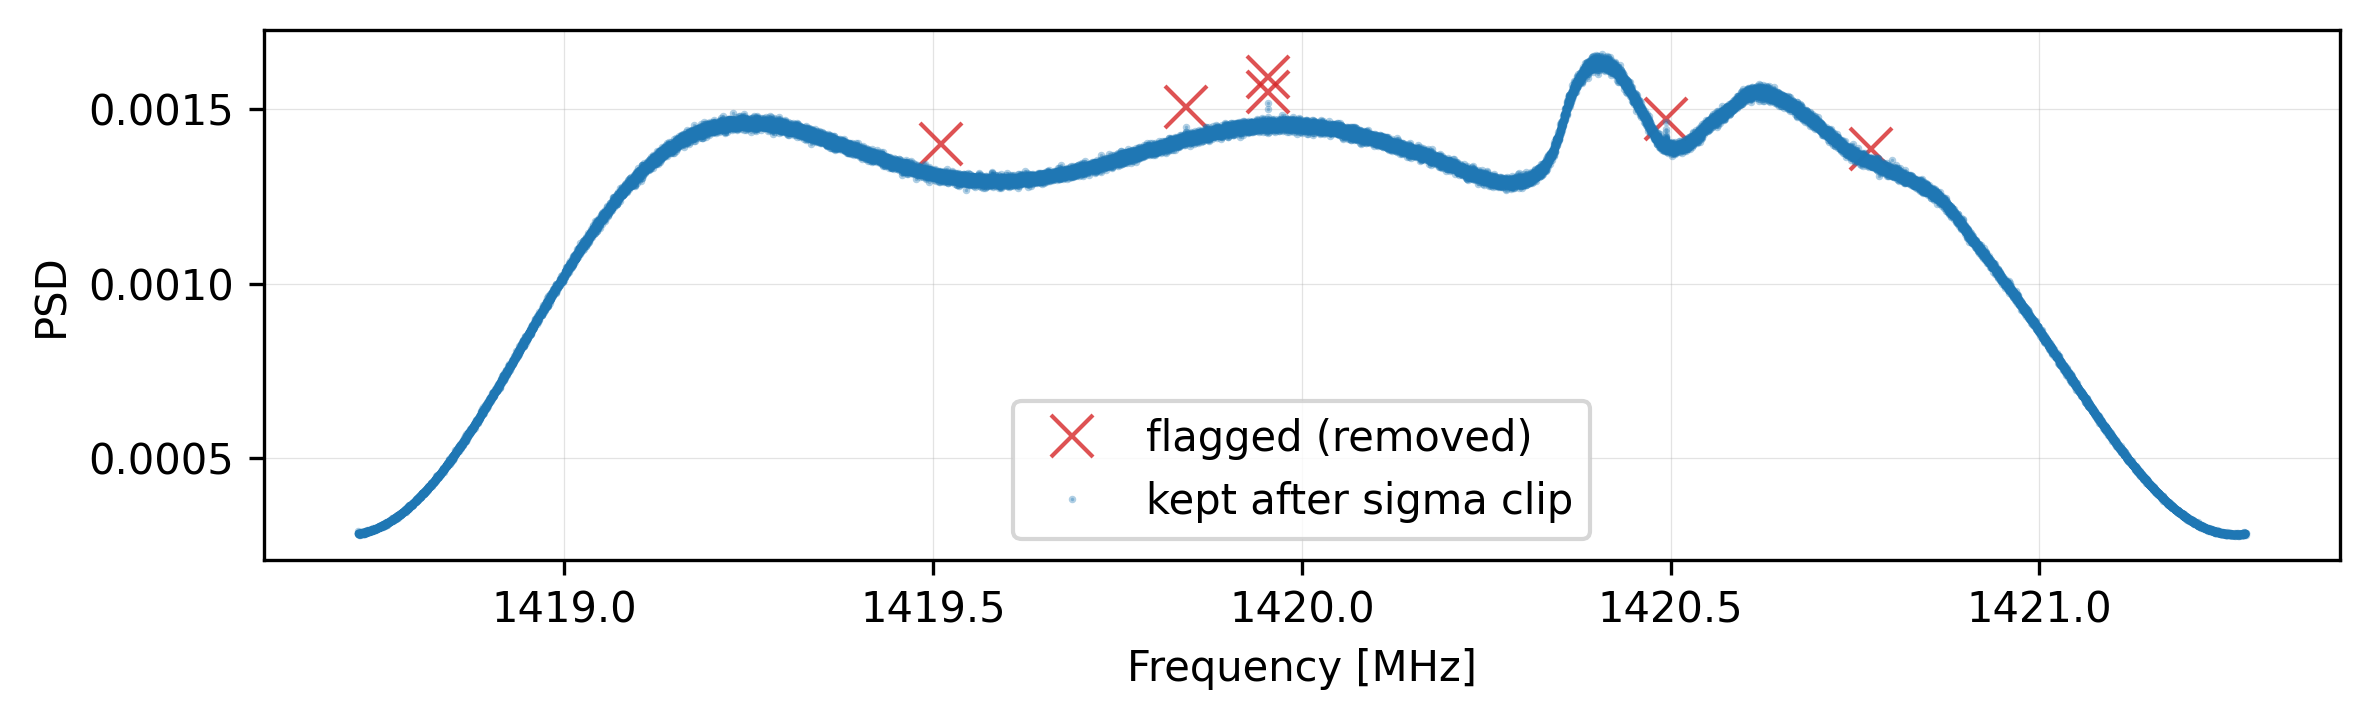

Equipment artifact (loaded):
  path                        : cache/equipment_calibration_results_v2.npz
  schema_version              : 2.0.0
  alpha_db_per_m              : 0.728112 +/- 0.126931
  unknown_cable_length_m      : 40.0589 +/- 7.3462
  linearity_rmse_db (median)  : 0.0979
  attenuation_frac raw/used   : 1.1708 / 0.0000
  attenuation model           : two_load_common_mode_cancelled
  combined hardware frac      : 0.0113
  response_floor              : 1.000e-02
  response_variant            : fir_times_sum
  response_support combined/fir : 0.9874 / 0.9874

Good / flagged bins per spectrum:
  human LO1420: RFI=8186/8192 ( 99.93%), PASS=8192/8192 (100.00%), EVAL=8089/8192 ( 98.74%), HW=8192/8192 (100.00%), final=8186/8192 ( 99.93%)
  human LO1421: RFI=8187/8192 ( 99.94%), PASS=8192/8192 (100.00%), EVAL=8089/8192 ( 98.74%), HW=8192/8192 (100.00%), final=8187/8192 ( 99.94%)
  cold_ref LO1420: RFI=8191/8192 ( 99.99%), PASS=8192/8192 (100.00%), EVAL=8089/8192 ( 98.74%), HW=8192/8

In [11]:
# Load all spectra
human_pair = load_lo_pair(DATA_ROOT / 'human_combined_spectra')
cold_ref_pair = load_lo_pair(DATA_ROOT / 'cold_ref_combined_spectra')
loaded_spectra = {}
loaded_lo_masks = {}
loaded_lo_center_bins = {}
for label, pair in [('human', human_pair), ('cold_ref', cold_ref_pair)]:
    for lo in [1420, 1421]:
        loaded_spectra[(label, lo)] = pair[lo]
        loaded_lo_masks[(label, lo)] = lo_analysis_mask(pair[lo])
        loaded_lo_center_bins[(label, lo)] = lo_center_bin_index(pair[lo])

# Load equipment artifact (hard requirement)
eq_path, eq = load_equipment_artifact()

hardware_systematic_frac, hardware_att_frac_raw, hardware_att_frac_used, hardware_rmse_db = hardware_systematic_fraction(eq)
eq_response_model, eq_response_variant, eq_response_diag = select_equipment_response_model(eq)

hardware = {
    'path': str(eq_path),
    'schema_version': str(eq['schema_version'].item() if np.asarray(eq['schema_version']).ndim == 0 else eq['schema_version']),
    'alpha_db_per_m': float(eq['alpha_db_per_m']),
    'sigma_alpha_db_per_m': float(eq['sigma_alpha_db_per_m']),
    'unknown_cable_length_m': float(eq['unknown_cable_length_m']),
    'unknown_cable_length_sigma_m': float(eq['unknown_cable_length_sigma_m']),
    'highest_unclipped_setpoint_dbm': float(eq['highest_unclipped_setpoint_dbm']),
    'first_clipped_setpoint_dbm': float(eq['first_clipped_setpoint_dbm']),
    'clip_threshold': float(eq['clip_threshold']) if 'clip_threshold' in eq else np.nan,
    'response_floor': max(float(eq['response_floor']), HARDWARE_RESPONSE_MIN),
    'linearity_rmse_db': float(hardware_rmse_db),
    'att_frac_raw': float(hardware_att_frac_raw),
    'att_frac_used': float(hardware_att_frac_used),
    'systematic_fraction': float(hardware_systematic_frac),
    'att_model': 'two_load_common_mode_cancelled',
    'response_variant': str(eq_response_variant),
    'response_support_combined': float(eq_response_diag['support_combined']),
    'response_support_fir': float(eq_response_diag['support_fir']),
}

# Build masks: RFI intersected with lax hardware-response support
masks_rfi = {}
hardware_masks = {}
hardware_response = {}
passband_masks = {}
eval_masks = {}
hardware_floors = []

for label, pair in [('human', human_pair), ('cold_ref', cold_ref_pair)]:
    for lo in [1420, 1421]:
        spec = pair[lo]
        rfi_mask = sigma_clip_rfi_mask(spec)
        resp, hw_mask, eff_floor, pass_mask, eval_mask = hardware_response_on_axis(eq, spec, eq_resp_model=eq_response_model)
        masks_rfi[(label, lo)] = rfi_mask
        hardware_masks[(label, lo)] = hw_mask
        hardware_response[(label, lo)] = resp
        passband_masks[(label, lo)] = pass_mask
        eval_masks[(label, lo)] = eval_mask
        hardware_floors.append(float(eff_floor))

hardware['response_floor'] = float(np.nanmin(hardware_floors)) if hardware_floors else hardware['response_floor']
masks = {
    key: combine_spectrum_mask(loaded_spectra[key], loaded_lo_masks[key], masks_rfi[key], hardware_masks[key], require_nonempty=True)
    for key in masks_rfi
}

# Identify the dataset with the most sigma-clipped bins under data/lab02
worst_info = None
for data_dir in sorted(DATA_ROOT.glob('*_combined_spectra')):
    try:
        pair = load_lo_pair(data_dir)
    except Exception:
        continue
    for lo, spec in pair.items():
        mask = sigma_clip_rfi_mask(spec)
        bad = int(np.sum(~mask))
        total = len(mask)
        if worst_info is None or bad > worst_info['bad']:
            worst_info = {
                'label': data_dir.name,
                'lo': lo,
                'spec': spec,
                'mask': mask,
                'bad': bad,
                'total': total,
            }

if worst_info is not None:
    worst_freqs = np.asarray(worst_info['spec'].freqs, float) / 1e6
    worst_psd = masked_spectrum_values(worst_info['spec'])
    worst_mask = combine_spectrum_mask(worst_info['spec'], worst_info['mask'])
    center_idx = lo_center_bin_index(worst_info['spec'])
    flagged_idxs = np.where(~worst_mask)[0]
    non_center_flagged = flagged_idxs[flagged_idxs != center_idx]
    if non_center_flagged.size >= 5:
        worst_mask[non_center_flagged[4]] = True
    fig, ax = plt.subplots(1, 1, figsize=(8, 2.5))
    ax.plot(
        worst_freqs[~worst_mask],
        worst_psd[~worst_mask],
        marker='x',
        ms=10,
        alpha=0.80,
        lw=0.0,
        color='tab:red',
        label='flagged (removed)',
    )
    ax.plot(
        worst_freqs[worst_mask],
        worst_psd[worst_mask],
        '.',
        ms=1.6,
        alpha=0.35,
        color='tab:blue',
        label='kept after sigma clip',
    )
    ax.set_xlabel('Frequency [MHz]')
    ax.set_ylabel('PSD')
    ax.grid(True, lw=0.3, alpha=0.35)
    ax.legend(loc='best')
    fig.tight_layout()
    _nb_dir = Path('labs/02') if Path('labs/02').exists() else Path('.')
    plt.savefig(_nb_dir / 'report' / 'figures' / 'sigma_masking.pdf', bbox_inches='tight')
    plt.show()

print('Equipment artifact (loaded):')
print(f"  path                        : {hardware['path']}")
print(f"  schema_version              : {hardware['schema_version']}")
print(f"  alpha_db_per_m              : {hardware['alpha_db_per_m']:.6f} +/- {hardware['sigma_alpha_db_per_m']:.6f}")
print(f"  unknown_cable_length_m      : {hardware['unknown_cable_length_m']:.4f} +/- {hardware['unknown_cable_length_sigma_m']:.4f}")
print(f"  linearity_rmse_db (median)  : {hardware['linearity_rmse_db']:.4f}")
print(f"  attenuation_frac raw/used   : {hardware['att_frac_raw']:.4f} / {hardware['att_frac_used']:.4f}")
print(f"  attenuation model           : {hardware['att_model']}")
print(f"  combined hardware frac      : {hardware['systematic_fraction']:.4f}")
print(f"  response_floor              : {hardware['response_floor']:.3e}")
print(f"  response_variant            : {hardware['response_variant']}")
print(f"  response_support combined/fir : {hardware['response_support_combined']:.4f} / {hardware['response_support_fir']:.4f}")
print()

print('Good / flagged bins per spectrum:')
for (label, lo) in [('human', 1420), ('human', 1421), ('cold_ref', 1420), ('cold_ref', 1421)]:
    mr = masks_rfi[(label, lo)]
    mh = hardware_masks[(label, lo)]
    mp = passband_masks[(label, lo)]
    me = eval_masks[(label, lo)]
    mf = masks[(label, lo)]
    print(
        f'  {label} LO{lo}: '
        f'RFI={np.sum(mr):4d}/{len(mr)} ({100*np.mean(mr):6.2f}%), '
        f'PASS={np.sum(mp):4d}/{len(mp)} ({100*np.mean(mp):6.2f}%), '
        f'EVAL={np.sum(me):4d}/{len(me)} ({100*np.mean(me):6.2f}%), '
        f'HW={np.sum(mh):4d}/{len(mh)} ({100*np.mean(mh):6.2f}%), '
        f'final={np.sum(mf):4d}/{len(mf)} ({100*np.mean(mf):6.2f}%)'
    )


## Y-factor solve (per LO) and uncertainty decomposition

For each LO, the notebook solves

$$
Y = \frac{P_{\mathrm{hot}}}{P_{\mathrm{cold}}},
\qquad
T_{\mathrm{rx}} = \frac{T_{\mathrm{hot}} - Y T_{\mathrm{cold}}}{Y - 1},
$$

using the **common hot/cold mask** for scalar power sums.

Reported outputs include:

- $Y$, $Y_{\mathrm{dB}}$,
- $T_{\mathrm{rx}}$,
- measurement/load/hardware uncertainty components and total quadrature uncertainty.


In [4]:
t_cold = {1420: T_COLD, 1421: T_COLD}

yfactor_results = {}
yfactor_common_masks = {}
for lo in [1420, 1421]:
    hot_mask = np.asarray(masks[('human', lo)], bool)
    cold_mask = np.asarray(masks[('cold_ref', lo)], bool)
    common_mask = hot_mask & cold_mask
    if not np.any(common_mask):
        raise ValueError(f'LO {lo}: no common valid channels for Y-factor solve.')

    yfactor_common_masks[lo] = common_mask
    p_hot, s_hot = masked_total_power(human_pair[lo], common_mask)
    p_cold, s_cold = masked_total_power(cold_ref_pair[lo], common_mask)

    yfactor_results[lo] = measure_y_factor(
        p_hot, s_hot, p_cold, s_cold,
        T_HOT, t_cold[lo],
        hardware_frac=hardware['systematic_fraction'],
        lo_mhz=lo,
    )

    if yfactor_results[lo].Y <= 1.0:
        raise ValueError(f'LO {lo}: non-physical Y <= 1 ({yfactor_results[lo].Y:.6f}).')

rows = []
for lo, r in yfactor_results.items():
    rows.append({
        'LO [MHz]':         lo,
        'N_common':         int(np.sum(yfactor_common_masks[lo])),
        'P_hot':            f'{r.P_hot:.4f}',
        'P_cold':           f'{r.P_cold:.4f}',
        'Y':                f'{r.Y:.6f}',
        'Y [dB]':           f'{r.Y_dB:.4f} +/- {r.sigma_Y_dB:.4f}',
        'T_rx [K]':         f'{r.T_rx:.2f}',
        'sigma_meas [K]':   f'{r.sigma_T_rx_meas:.2f}',
        'sigma_loads [K]':  f'{r.sigma_T_rx_loads:.2f}',
        'sigma_hw [K]':     f'{r.sigma_T_rx_hw:.2f}',
        'sigma_total [K]':  f'{r.sigma_T_rx_total:.2f}',
    })

display(pd.DataFrame(rows).set_index('LO [MHz]'))

for lo, r in yfactor_results.items():
    print(f'LO {lo} MHz:')
    print(f'  common-mask bins = {int(np.sum(yfactor_common_masks[lo]))}')
    print(f'  Y                = {r.Y:.6f} +/- {r.sigma_Y:.6f}')
    print(f'  Y_dB             = {r.Y_dB:.4f} +/- {r.sigma_Y_dB:.4f} dB')
    print(f'  T_rx             = {r.T_rx:.2f} K')
    print(f'  sigma_T_rx(meas) = {r.sigma_T_rx_meas:.2f} K')
    print(f'  sigma_T_rx(load) = {r.sigma_T_rx_loads:.2f} K')
    print(f'  sigma_T_rx(hw)   = {r.sigma_T_rx_hw:.2f} K  (frac={r.sigma_hw_frac:.4f})')
    print(f'  sigma_T_rx(total)= {r.sigma_T_rx_total:.2f} K')

,N_common,P_hot,P_cold,Y,Y [dB],T_rx [K],sigma_meas [K],sigma_loads [K],sigma_hw [K],sigma_total [K]
LO [MHz],,,,,,,,,,
1420,8186,110.3375,30.9575,3.564157,5.5196 +/- 0.0005,79.20,0.02,3.40,0.89,3.51
1421,8187,107.3707,33.3716,3.217428,5.0751 +/- 0.0005,96.27,0.02,3.68,1.08,3.83


LO 1420 MHz:
  common-mask bins = 8186
  Y                = 3.564157 +/- 0.000396
  Y_dB             = 5.5196 +/- 0.0005 dB
  T_rx             = 79.20 K
  sigma_T_rx(meas) = 0.02 K
  sigma_T_rx(load) = 3.40 K
  sigma_T_rx(hw)   = 0.89 K  (frac=0.0113)
  sigma_T_rx(total)= 3.51 K
LO 1421 MHz:
  common-mask bins = 8187
  Y                = 3.217428 +/- 0.000357
  Y_dB             = 5.0751 +/- 0.0005 dB
  T_rx             = 96.27 K
  sigma_T_rx(meas) = 0.02 K
  sigma_T_rx(load) = 3.68 K
  sigma_T_rx(hw)   = 1.08 K  (frac=0.0113)
  sigma_T_rx(total)= 3.83 K


### Per-channel diagnostics: $Y(\nu)$ and $T_{\mathrm{rx}}(\nu)$

Beyond scalar solves, we inspect channel-wise structure:

- $Y(\nu)=P_{\mathrm{hot}}(\nu)/P_{\mathrm{cold}}(\nu)$,
- implied per-channel $T_{\mathrm{rx}}(\nu)$.

Overlaying LO1420 and LO1421 on a common frequency axis tests overlap-region consistency and reveals edge-response behavior.


In [5]:
# ── Per-channel Y-factor spectrum ────────────────────────────────────────────
y_spec    = {}   # Y(f) per LO
sy_spec   = {}   # σ_Y(f)
trx_spec  = {}   # T_rx(f) per LO

for lo in [1420, 1421]:
    mask = np.asarray(yfactor_common_masks[lo], bool)
    p_h = masked_spectrum_values(human_pair[lo], mask=mask)
    s_h = masked_spectrum_values(human_pair[lo], human_pair[lo].std, mask=mask)
    p_c = masked_spectrum_values(cold_ref_pair[lo], mask=mask)
    s_c = masked_spectrum_values(cold_ref_pair[lo], cold_ref_pair[lo].std, mask=mask)

    with np.errstate(divide='ignore', invalid='ignore'):
        y = p_h / p_c
        sy = y * np.sqrt((s_h / p_h)**2 + (s_c / p_c)**2)
        trx = (T_HOT - y * T_COLD) / (y - 1)

    y_spec[lo] = y
    sy_spec[lo] = sy
    trx_spec[lo] = trx

print('Per-channel Y-factor computed for LO 1420 and 1421 with the LO center bin excluded at load time.')


Per-channel Y-factor computed for LO 1420 and 1421 with the LO center bin excluded at load time.


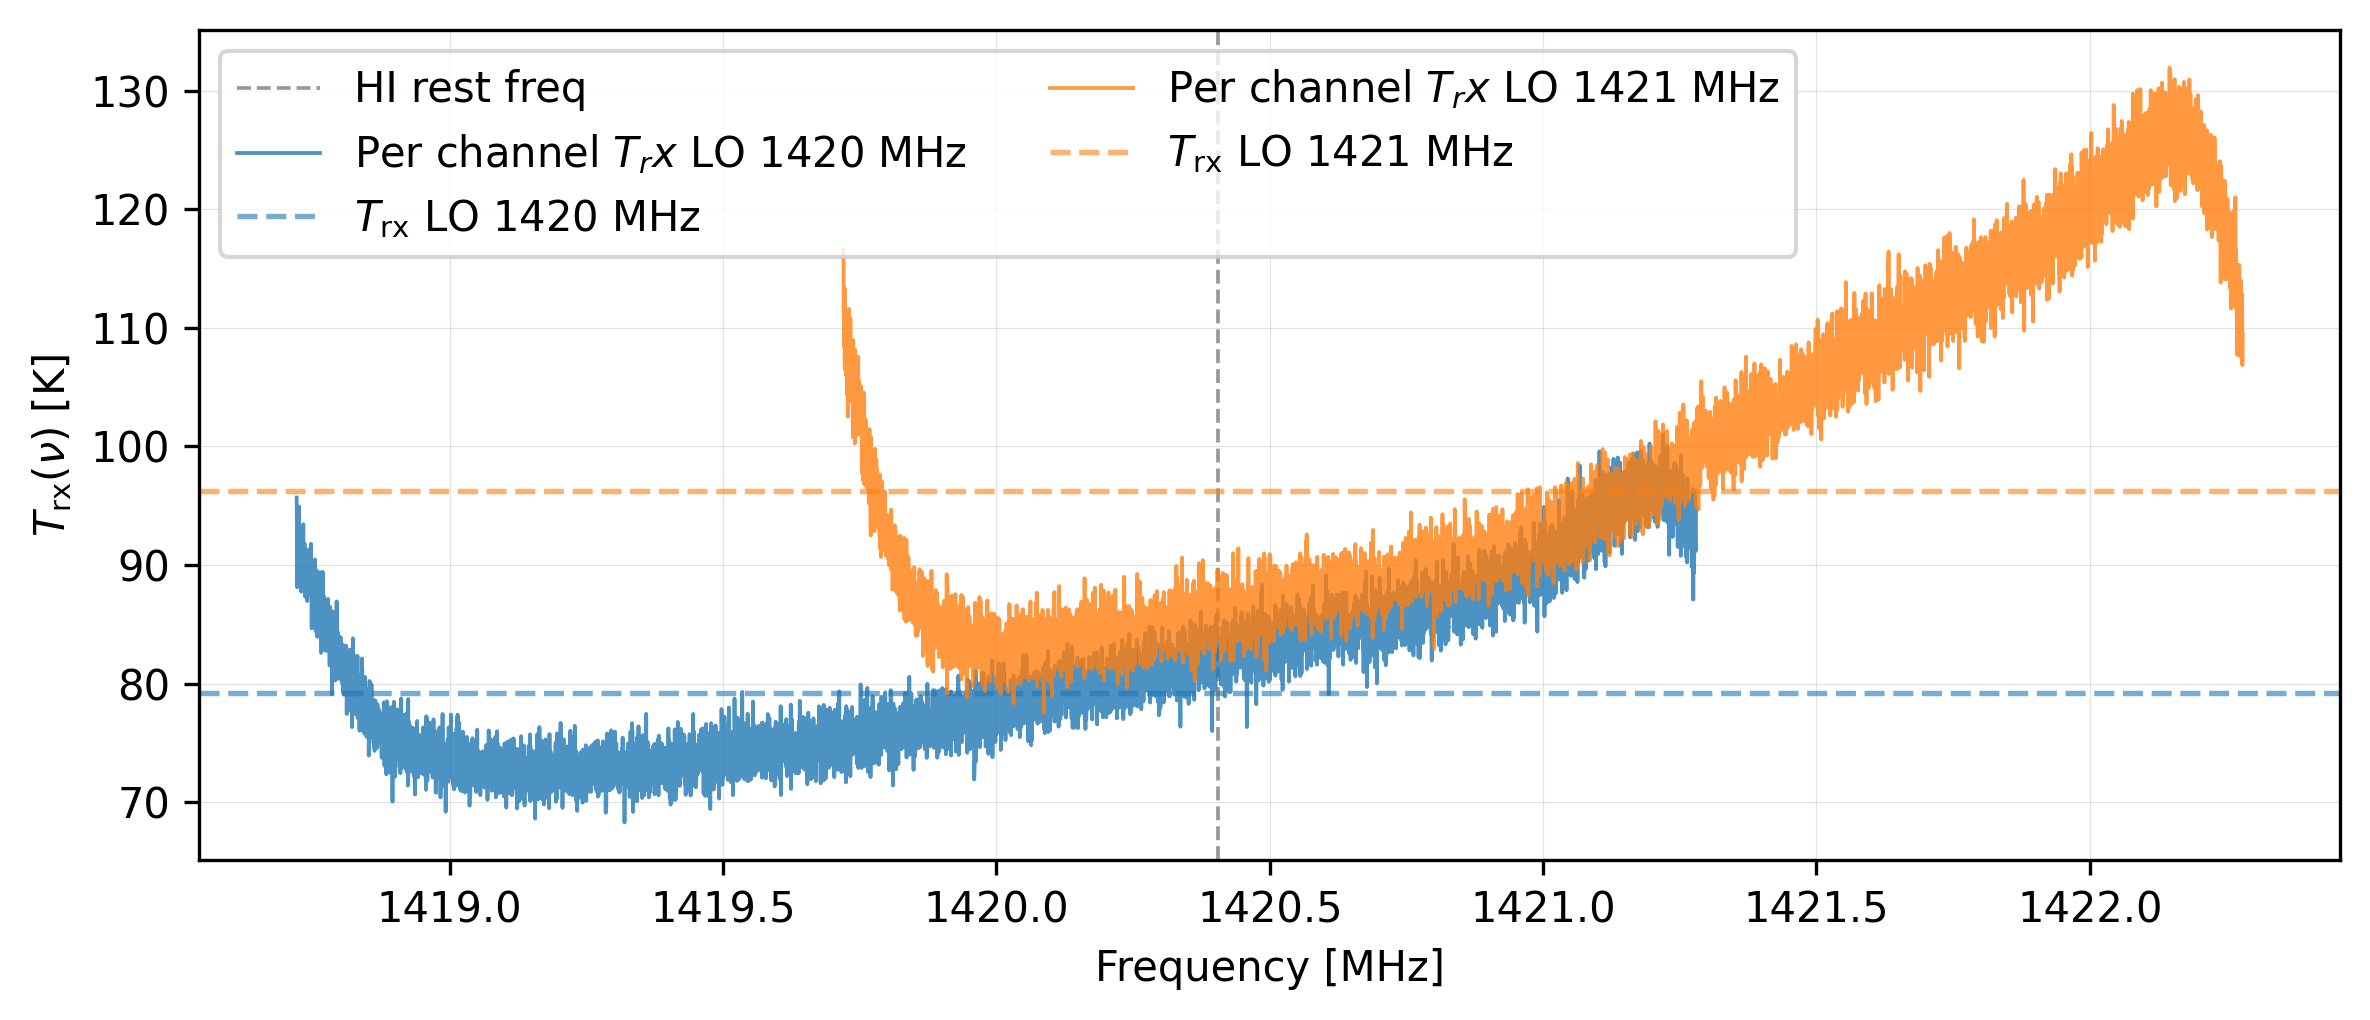

Figure saved -> /Users/junruiting/GitHub/ay-121/labs/02/report/figures/per_frequency_trx.pdf


In [10]:
fig, ax = plt.subplots(1, 1, figsize=(8, 3.5))
COLORS = {1420: '#1f77b4', 1421: '#ff7f0e'}
HI_FREQ_MHZ = 1420.405751768
ax.axvline(HI_FREQ_MHZ, ls='--', lw=0.9, color='grey', alpha=0.8, label='HI rest freq')
for lo in [1420, 1421]:
    freqs_mhz = human_pair[lo].freqs / 1e6
    mask = yfactor_common_masks[lo]
    trx = trx_spec[lo]
    ax.plot(freqs_mhz[mask], trx[mask], lw=0.9, alpha=0.8,
            color=COLORS[lo], label=r'Per channel $T_rx$' + f' LO {lo} MHz')
    scalar_trx = yfactor_results[lo].T_rx
    ax.axhline(scalar_trx, ls='--', lw=1.3, color=COLORS[lo], alpha=0.6, label=r'$T_{\rm rx}$' + f' LO {lo} MHz')

ax.set_ylabel(r'$T_{\mathrm{rx}}(\nu)$ [K]')
ax.set_xlabel('Frequency [MHz]')
ax.grid(True, lw=0.3, alpha=0.35)
ax.legend(ncols=2, loc='upper left')
fig.tight_layout()
_nb_dir = Path('labs/02') if Path('labs/02').exists() else Path('.')
out_pdf = _nb_dir / 'report' / 'figures' / 'per_frequency_trx.pdf'
plt.savefig(out_pdf, bbox_inches='tight')
plt.show()
print(f'Figure saved -> {out_pdf.resolve()}')


**Observations and interpretation checklist**

- **Smoothness**: $Y(\nu)$ should vary slowly across well-behaved passband regions.
- **Overlap consistency**: LO1420 and LO1421 should broadly agree in their shared frequency region.
- **Edge caution**: deviations near filter roll-off are expected where backend response support declines.
- **Sensitivity near $Y\approx1$**: per-channel $T_{\mathrm{rx}}(\nu)$ scatter is amplified when $(Y-1)$ is small.

Use the printed scalar results from the solve cell as authoritative run-specific values.


## Numerical cross-check: Y-factor vs cool-method scalar form

This diagnostic computes $T_{\mathrm{sys}}$ via two algebraically equivalent paths:

1. Y-factor path: $T_{\mathrm{sys}} = T_{\mathrm{cold}} + T_{\mathrm{rx}}$.
2. Cool-method scalar path:
   $$
   T_{\mathrm{sys}} = \frac{\sum P_{\mathrm{cold}}}{\sum(P_{\mathrm{hot}}-P_{\mathrm{cold}})}(T_{\mathrm{hot}}-T_{\mathrm{cold}}).
   $$

The common-mask comparison should match to numerical precision; separate-mask differences are reported only as diagnostics.


In [7]:
cross_rows = []

for lo in [1420, 1421]:
    hot_spec = human_pair[lo]
    cold_spec = cold_ref_pair[lo]

    hot_mask = np.asarray(masks[('human', lo)], bool)
    cold_mask = np.asarray(masks[('cold_ref', lo)], bool)
    common_mask = hot_mask & cold_mask

    if not np.any(common_mask):
        raise ValueError(f'LO {lo}: no common valid channels for cool-method cross-check.')

    p_hot_common, _ = masked_total_power(hot_spec, common_mask)
    p_cold_common, _ = masked_total_power(cold_spec, common_mask)
    denom_common = p_hot_common - p_cold_common
    if not np.isfinite(denom_common) or denom_common <= 0:
        raise ValueError(f'LO {lo}: non-physical cool-method denominator (common mask).')

    # Strict equivalence check on the same common channel set.
    y_common = p_hot_common / p_cold_common
    if y_common <= 1:
        raise ValueError(f'LO {lo}: non-physical Y<=1 on common-mask channels.')
    t_rx_y_common = (T_HOT - y_common * T_COLD) / (y_common - 1.0)
    t_sys_y_common = float(T_COLD + t_rx_y_common)

    t_sys_cool_common = float((p_cold_common / denom_common) * (T_HOT - T_COLD))

    # Production Y-factor result uses each spectrum's own mask.
    t_sys_y_production = float(yfactor_results[lo].T_rx + yfactor_results[lo].T_cold)

    # Separate-mask cool variant (diagnostic only): non-identical channel sets introduce tiny offsets.
    p_hot_sep, _ = masked_total_power(hot_spec, hot_mask)
    p_cold_sep, _ = masked_total_power(cold_spec, cold_mask)
    denom_sep = p_hot_sep - p_cold_sep
    if not np.isfinite(denom_sep) or denom_sep <= 0:
        raise ValueError(f'LO {lo}: non-physical cool-method denominator (separate masks).')
    t_sys_cool_sep = float((p_cold_sep / denom_sep) * (T_HOT - T_COLD))

    cross_rows.append({
        'LO [MHz]': lo,
        'N_common': int(np.sum(common_mask)),
        'T_sys (Y, common mask) [K]': t_sys_y_common,
        'T_sys (cool, common mask) [K]': t_sys_cool_common,
        'Δ(common cool - common Y) [K]': t_sys_cool_common - t_sys_y_common,
        'T_sys (Y, production masks) [K]': t_sys_y_production,
        'Δ(prod Y - common Y) [K]': t_sys_y_production - t_sys_y_common,
        'T_sys (cool, separate masks) [K]': t_sys_cool_sep,
        'Δ(separate cool - common Y) [K]': t_sys_cool_sep - t_sys_y_common,
    })

cross_df = pd.DataFrame(cross_rows).set_index('LO [MHz]')
display(cross_df)

print('Cross-check interpretation:')
print('  - Common-mask cool vs common-mask Y should agree to numerical precision.')
print('  - Production Y-factor now uses the common-mask policy; separate-mask deltas are diagnostic only.')


,N_common,"T_sys (Y, common mask) [K]","T_sys (cool, common mask) [K]",Δ(common cool - common Y) [K],"T_sys (Y, production masks) [K]",Δ(prod Y - common Y) [K],"T_sys (cool, separate masks) [K]",Δ(separate cool - common Y) [K]
LO [MHz],,,,,,,,
1420,8186,109.197667,109.197667,-1.421085e-14,109.197667,0.0,109.309971,0.112304
1421,8187,126.272438,126.272438,0.000000e+00,126.272438,0.0,126.348011,0.075573


Cross-check interpretation:
  - Common-mask cool vs common-mask Y should agree to numerical precision.
  - Production Y-factor now uses the common-mask policy; separate-mask deltas are diagnostic only.


## Export calibration contract (`cache/calibration_results_v2.npz`)

This cell writes the downstream calibration artifact and verifies reload integrity.

Science-critical groups persisted in the artifact:

- scalar calibration terms: `t_rx_*`, `sigma_t_rx_*`, `t_hot`, `t_cold`,
- uncertainty decomposition and hardware systematic fraction,
- frequency-dependent cold-reference profiles/masks/frequency axes,
- hardware provenance and mask-strategy metadata,
- diagnostic metadata needed for downstream checks.

The preflight key check at the end confirms downstream analysis compatibility.


In [8]:
r1420 = yfactor_results[1420]
r1421 = yfactor_results[1421]

# Cold-reference total powers used for Y-factor provenance
p_cold_total_1420, _ = masked_total_power(cold_ref_pair[1420], yfactor_common_masks[1420])
p_cold_total_1421, _ = masked_total_power(cold_ref_pair[1421], yfactor_common_masks[1421])

# Frequency-dependent cold-reference profiles and masks (hardware-response corrected, common-mask policy)
resp_1420 = hardware_response[('cold_ref', 1420)]
resp_1421 = hardware_response[('cold_ref', 1421)]

cold_ref_profile_1420 = build_cold_reference_profile(
    cold_ref_pair[1420],
    yfactor_common_masks[1420],
    smooth_kwargs=SAVGOL,
    response=resp_1420,
    response_floor=hardware['response_floor'],
)
cold_ref_profile_1421 = build_cold_reference_profile(
    cold_ref_pair[1421],
    yfactor_common_masks[1421],
    smooth_kwargs=SAVGOL,
    response=resp_1421,
    response_floor=hardware['response_floor'],
)

cold_ref_mask_1420 = np.asarray(yfactor_common_masks[1420], bool)
cold_ref_mask_1421 = np.asarray(yfactor_common_masks[1421], bool)

cold_ref_mask_stats_1420, lo_center_bin_index_1420 = omit_lo_center_bin_mask(cold_ref_pair[1420], cold_ref_mask_1420)
cold_ref_mask_stats_1421, lo_center_bin_index_1421 = omit_lo_center_bin_mask(cold_ref_pair[1421], cold_ref_mask_1421)
freq_hz_1420 = np.asarray(cold_ref_pair[1420].freqs, float)
freq_hz_1421 = np.asarray(cold_ref_pair[1421].freqs, float)

# Optional diagnostics for downstream notebooks
delta_nu_hz_1420 = float(cold_ref_pair[1420].bin_width)
delta_nu_hz_1421 = float(cold_ref_pair[1421].bin_width)
tau_s_1420 = float(cold_ref_pair[1420].nblocks * cold_ref_pair[1420].nsamples / cold_ref_pair[1420].sample_rate)
tau_s_1421 = float(cold_ref_pair[1421].nblocks * cold_ref_pair[1421].nsamples / cold_ref_pair[1421].sample_rate)

omega_beam_approx_sr_1420 = float((C_LIGHT_M_S / cold_ref_pair[1420].center_freq) ** 2 / HORN_APERTURE_AREA_M2)
omega_beam_approx_sr_1421 = float((C_LIGHT_M_S / cold_ref_pair[1421].center_freq) ** 2 / HORN_APERTURE_AREA_M2)

# Determine output path relative to this notebook cache directory
out_path = CACHE_DIR / 'calibration_results_v2.npz'

np.savez(
    str(out_path),
    t_rx_1420              = np.float64(r1420.T_rx),
    sigma_t_rx_1420        = np.float64(r1420.sigma_T_rx_total),
    sigma_t_rx_meas_1420   = np.float64(r1420.sigma_T_rx_meas),
    sigma_t_rx_loads_1420  = np.float64(r1420.sigma_T_rx_loads),
    sigma_t_rx_hw_1420     = np.float64(r1420.sigma_T_rx_hw),

    t_rx_1421              = np.float64(r1421.T_rx),
    sigma_t_rx_1421        = np.float64(r1421.sigma_T_rx_total),
    sigma_t_rx_meas_1421   = np.float64(r1421.sigma_T_rx_meas),
    sigma_t_rx_loads_1421  = np.float64(r1421.sigma_T_rx_loads),
    sigma_t_rx_hw_1421     = np.float64(r1421.sigma_T_rx_hw),

    sigma_hw_fraction      = np.float64(hardware['systematic_fraction']),

    t_cold                 = np.float64(T_COLD),
    t_cold_1420            = np.float64(T_COLD),
    t_cold_1421            = np.float64(T_COLD),
    t_hot                  = np.float64(T_HOT),
    p_cold_total_1420      = np.float64(p_cold_total_1420),
    p_cold_total_1421      = np.float64(p_cold_total_1421),

    # Frequency-dependent cold reference schema
    cold_ref_profile_1420  = np.asarray(cold_ref_profile_1420, dtype=np.float64),
    cold_ref_profile_1421  = np.asarray(cold_ref_profile_1421, dtype=np.float64),
    cold_ref_mask_1420     = np.asarray(cold_ref_mask_1420, dtype=bool),
    cold_ref_mask_1421     = np.asarray(cold_ref_mask_1421, dtype=bool),
    freq_hz_1420           = np.asarray(freq_hz_1420, dtype=np.float64),
    freq_hz_1421           = np.asarray(freq_hz_1421, dtype=np.float64),
    cold_ref_method        = np.str_('savgol_profile_from_cold_ref_sky_l165_b36_hw_corrected_lo_masked'),
    calibration_mask_method = np.str_('rfi_sigma_clip_and_lax_hardware_response_support_lo_masked'),
    cold_ref_savgol_window_length = np.int64(SAVGOL['window_length']),
    cold_ref_savgol_polyorder     = np.int64(SAVGOL['polyorder']),

    # Hardware provenance terms from equipment artifact
    equipment_artifact_path = np.str_(hardware['path']),
    equipment_schema_version = np.str_(hardware['schema_version']),
    alpha_db_per_m = np.float64(hardware['alpha_db_per_m']),
    sigma_alpha_db_per_m = np.float64(hardware['sigma_alpha_db_per_m']),
    unknown_cable_length_m = np.float64(hardware['unknown_cable_length_m']),
    unknown_cable_length_sigma_m = np.float64(hardware['unknown_cable_length_sigma_m']),
    highest_unclipped_setpoint_dbm = np.float64(hardware['highest_unclipped_setpoint_dbm']),
    first_clipped_setpoint_dbm = np.float64(hardware['first_clipped_setpoint_dbm']),
    clip_threshold = np.float64(hardware['clip_threshold']),
    hardware_response_floor = np.float64(hardware['response_floor']),
    hardware_linearity_rmse_db = np.float64(hardware['linearity_rmse_db']),
    hardware_att_frac_raw = np.float64(hardware['att_frac_raw']),
    hardware_att_frac_used = np.float64(hardware['att_frac_used']),
    hardware_mask_1420 = np.asarray(hardware_masks[('cold_ref', 1420)], dtype=bool),
    hardware_mask_1421 = np.asarray(hardware_masks[('cold_ref', 1421)], dtype=bool),
    hardware_response_1420 = np.asarray(resp_1420, dtype=np.float64),
    hardware_response_1421 = np.asarray(resp_1421, dtype=np.float64),
    hardware_response_variant = np.str_(hardware.get('response_variant', 'unknown')),
    hardware_response_support_combined = np.float64(hardware.get('response_support_combined', np.nan)),
    hardware_response_support_fir = np.float64(hardware.get('response_support_fir', np.nan)),

    # Physics metadata / diagnostics
    horn_parallel_m              = np.float64(HORN_PARALLEL_M),
    horn_perpendicular_horizon_m = np.float64(HORN_PERP_HORIZON_M),
    horn_aperture_area_m2        = np.float64(HORN_APERTURE_AREA_M2),
    beam_filling_factor_default  = np.float64(BEAM_FILLING_FACTOR_DEFAULT),
    omega_beam_approx_sr_hi      = np.float64(OMEGA_BEAM_APPROX_SR_HI),
    delta_nu_hz_1420             = np.float64(delta_nu_hz_1420),
    delta_nu_hz_1421             = np.float64(delta_nu_hz_1421),
    tau_s_1420                   = np.float64(tau_s_1420),
    tau_s_1421                   = np.float64(tau_s_1421),
    omega_beam_approx_sr_1420    = np.float64(omega_beam_approx_sr_1420),
    omega_beam_approx_sr_1421    = np.float64(omega_beam_approx_sr_1421),

temperature_scale_mode       = np.str_('antenna_temperature_yfactor_freq_ref_profile_hw_aware'),

# Contract/traceability metadata
hardware_mask_strategy = np.str_('lax_response_support_with_passband_eval_diagnostics'),
yfactor_mask_strategy = np.str_('common_hot_cold_intersection'),
theory_traceability_version = np.str_('temperature_calibration_trace_v3_lo_mask_loadtime'),
stats_exclude_lo_center_bin = np.bool_(True),
lo_center_bin_index_1420 = np.int64(lo_center_bin_index_1420),
lo_center_bin_index_1421 = np.int64(lo_center_bin_index_1421),
hardware_eval_mask_fraction_1420 = np.float64(np.mean(eval_masks[('cold_ref', 1420)])),
hardware_eval_mask_fraction_1421 = np.float64(np.mean(eval_masks[('cold_ref', 1421)])),
hardware_passband_mask_fraction_1420 = np.float64(np.mean(passband_masks[('cold_ref', 1420)])),
hardware_passband_mask_fraction_1421 = np.float64(np.mean(passband_masks[('cold_ref', 1421)])),
)

print(f'Saved calibration results to: {out_path.resolve()}')
print()

cal = np.load(str(out_path), allow_pickle=False)
print('Verification (reloaded):')
for key in cal.files:
    value = cal[key]
    if np.issubdtype(value.dtype, np.number):
        if value.ndim == 0:
            print(f'  {key:32s} = {float(value):.6g}')
        else:
            print(
                f'  {key:32s} shape={value.shape} '
                f'min={float(np.nanmin(value)):.6g} '
                f'median={float(np.nanmedian(value)):.6g} '
                f'max={float(np.nanmax(value)):.6g}'
            )
    elif value.dtype == np.bool_:
        print(f'  {key:32s} shape={value.shape} true_frac={np.mean(value):.4f}')
    else:
        print(f'  {key:32s} = {value.item()}')

print()

# Downstream contract preflight (analysis.ipynb compatibility)
ANALYSIS_REQUIRED_KEYS = [
    't_rx_1420', 'sigma_t_rx_1420',
    't_rx_1421', 'sigma_t_rx_1421',
    't_cold', 't_hot',
    'cold_ref_profile_1420', 'cold_ref_profile_1421',
    'cold_ref_mask_1420', 'cold_ref_mask_1421',
    'freq_hz_1420', 'freq_hz_1421',
]
missing_analysis_keys = [k for k in ANALYSIS_REQUIRED_KEYS if k not in cal.files]
if missing_analysis_keys:
    raise KeyError(f'{out_path.name} missing analysis keys: {missing_analysis_keys}')
print(f'Analysis contract preflight: PASS ({len(ANALYSIS_REQUIRED_KEYS)} required keys present)')

print('Summary table:')
summary = pd.DataFrame([
    {
        'LO [MHz]': 1420,
        'T_rx [K]': f"{r1420.T_rx:.2f} +/- {r1420.sigma_T_rx_meas:.2f} (meas) +/- {r1420.sigma_T_rx_loads:.2f} (loads) +/- {r1420.sigma_T_rx_hw:.2f} (hw) +/- {r1420.sigma_T_rx_total:.2f} (total)",
        'T_cold [K]': T_COLD,
        'T_hot [K]': T_HOT,
        'Y': f"{r1420.Y:.4f}",
        'Y_dB': f"{r1420.Y_dB:.3f} dB",
        'P_cold_ref med': f"{np.nanmedian(cold_ref_profile_1420[cold_ref_mask_stats_1420]):.6f}",
        'P_cold_total': f"{p_cold_total_1420:.4f}",
        'HW frac': f"{hardware['systematic_fraction']:.4f}",
    },
    {
        'LO [MHz]': 1421,
        'T_rx [K]': f"{r1421.T_rx:.2f} +/- {r1421.sigma_T_rx_meas:.2f} (meas) +/- {r1421.sigma_T_rx_loads:.2f} (loads) +/- {r1421.sigma_T_rx_hw:.2f} (hw) +/- {r1421.sigma_T_rx_total:.2f} (total)",
        'T_cold [K]': T_COLD,
        'T_hot [K]': T_HOT,
        'Y': f"{r1421.Y:.4f}",
        'Y_dB': f"{r1421.Y_dB:.3f} dB",
        'P_cold_ref med': f"{np.nanmedian(cold_ref_profile_1421[cold_ref_mask_stats_1421]):.6f}",
        'P_cold_total': f"{p_cold_total_1421:.4f}",
        'HW frac': f"{hardware['systematic_fraction']:.4f}",
    },
]).set_index('LO [MHz]')
display(summary)


Saved calibration results to: /Users/junruiting/GitHub/ay-121/labs/02/cache/calibration_results_v2.npz

Verification (reloaded):
  t_rx_1420                        = 79.1977
  sigma_t_rx_1420                  = 3.51104
  sigma_t_rx_meas_1420             = 0.0168504
  sigma_t_rx_loads_1420            = 3.39568
  sigma_t_rx_hw_1420               = 0.892461
  t_rx_1421                        = 96.2724
  sigma_t_rx_1421                  = 3.83185
  sigma_t_rx_meas_1421             = 0.0203357
  sigma_t_rx_loads_1421            = 3.67501
  sigma_t_rx_hw_1421               = 1.08487
  sigma_hw_fraction                = 0.0112688
  t_cold                           = 30
  t_cold_1420                      = 30
  t_cold_1421                      = 30
  t_hot                            = 310
  p_cold_total_1420                = 30.9575
  p_cold_total_1421                = 33.3716
  cold_ref_profile_1420            shape=(8192,) min=0.00431432 median=0.0049097 max=0.00595891
  cold_ref_profile_142

,T_rx [K],T_cold [K],T_hot [K],Y,Y_dB,P_cold_ref med,P_cold_total,HW frac
LO [MHz],,,,,,,,
1420,79.20 +/- 0.02 (meas) +/- 3.40 (loads) +/- 0.8...,30.0,310.0,3.5642,5.520 dB,0.004910,30.9575,0.0113
1421,96.27 +/- 0.02 (meas) +/- 3.68 (loads) +/- 1.0...,30.0,310.0,3.2174,5.075 dB,0.005286,33.3716,0.0113


## Downstream handoff (Part 3 analysis)

Use `cache/calibration_results_v2.npz` as the calibration contract for science extraction notebooks.

Recommended downstream usage:

1. Load `t_rx_*`, `cold_ref_profile_*`, `cold_ref_mask_*`, and `freq_hz_*`.
2. Apply the same validity/masking conventions used during calibration.
3. Build temperature-calibrated line products on the analysis velocity grid.
4. Propagate uncertainty with the same measurement + load-prior + hardware decomposition.
5. Perform baseline modeling, velocity-frame corrections, Gaussian decomposition, and aperture-efficiency inference in the analysis notebook.

Aperture-efficiency estimation is intentionally handled outside this Part-2 calibration notebook.
